In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import seaborn as sns
import pandas as pd
import sys

sys.path.append('..')
from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [2]:
RANDOM_STATE = 264034
N_SAMPLES = 2634
# N_SAMPLES = 500 # testing with less samples
MAXITER = 10
MAXITER_LINEAR = 5

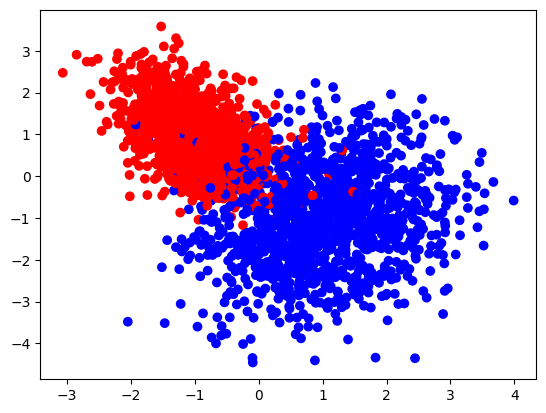

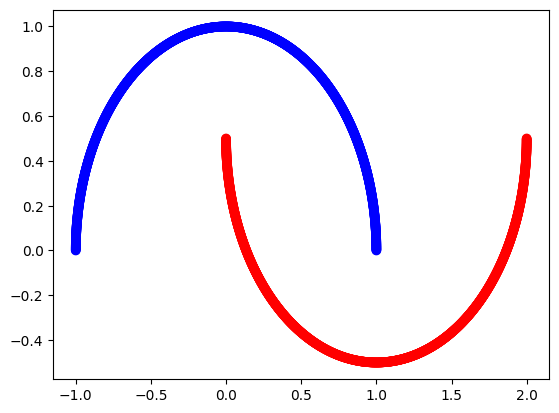

In [3]:
X_classification, y_classification = make_classification(
    n_samples = N_SAMPLES, n_clusters_per_class=1, n_features = 2, 
    n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()

________

# Implementation of Linear SVM

In [4]:
class LinearSVM(ClassifierAbstraction):
    def __init__(self, maxiter = MAXITER_LINEAR) -> None:
        self.weight = None
        self.bias = None
        self.lambdas = None
        self.maxiter = maxiter

    # def _loss(self, lambdas, X, y):
    #     n_samples = X.shape[0]
        
    #     left_term = 0.0
    #     for i in range(n_samples):
    #         left_term += lambdas[i]

    #     right_term = 0.0
    #     for i in range(n_samples):
    #         for j in range(n_samples):
    #             right_term += lambdas[i] * lambdas[j] * y[i] * y[j] * (X[i] @ X[j])

    #     return -(left_term - 0.5 * right_term)

    # def _loss(self, lambdas, X, y):
    #     left_term = np.sum(lambdas)

    #     right_term = 0.5 * np.sum(np.outer(lambdas, lambdas) * np.outer(y, y) * (X @ X.T))

    #     return -(left_term - right_term)

    def _loss(self, lambdas, XX, yy):
            left_term = np.sum(lambdas)

            right_term = 0.5 * np.sum(np.outer(lambdas, lambdas) * yy * XX)

            return -(left_term - right_term)
    

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples, n_features = X.shape
        y = np.where(y == 0, -1, 1)
        XX = (X @ X.T)
        yy = np.outer(y, y)

        lambdas_init = np.zeros(n_samples)

        bounds = [(0, None)] * n_samples

        result = minimize(
            fun=self._loss,
            x0=lambdas_init,
            args=(XX, yy),
            bounds=bounds,
            constraints={'type': 'eq', 'fun': lambda lambdas: np.dot(lambdas, y)},
            options={"maxiter": self.maxiter},
        )

        self.lambdas = result.x

        self.weight = (self.lambdas * y) @ X

        # sv_mask = self.lambdas > 1e-5
        # self.bias = np.mean(y[sv_mask] - X[sv_mask] @ self.weight)
        self.bias = np.mean(y - X @ self.weight)
            
    def predict(self, X) -> np.ndarray:
        raw = np.sign(X @ self.weight + self.bias)
        return np.where(raw == -1, 0, 1)
    
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weight + self.bias

### Testing on synthetic data

meassuring fit time using classification dataset 

In [5]:
# sk_svm = SVC(kernel='linear')
# my_svm = LinearSVM(maxiter=10)

# X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
#     X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE)

# print(f"sk fit time for 100 runs: {measure_fit_time(sk_svm, X_train_clf, y_train_clf)}")
# print(f"my fit time for 100 runs: {measure_fit_time(my_svm, X_train_clf, y_train_clf, n_runs=2)}")

moons dataset


── My SVM ──
Confusion matrix:
[[337  59]
 [ 76 319]]
Accuracy:       0.8293299620733249
Recall:         0.8075949367088607
Specificity:    0.851010101010101

── Sklearn SVM ──
Confusion matrix:
[[352  44]
 [ 51 344]]
Accuracy:       0.8798988621997471
Recall:         0.8708860759493671
Specificity:    0.8888888888888888


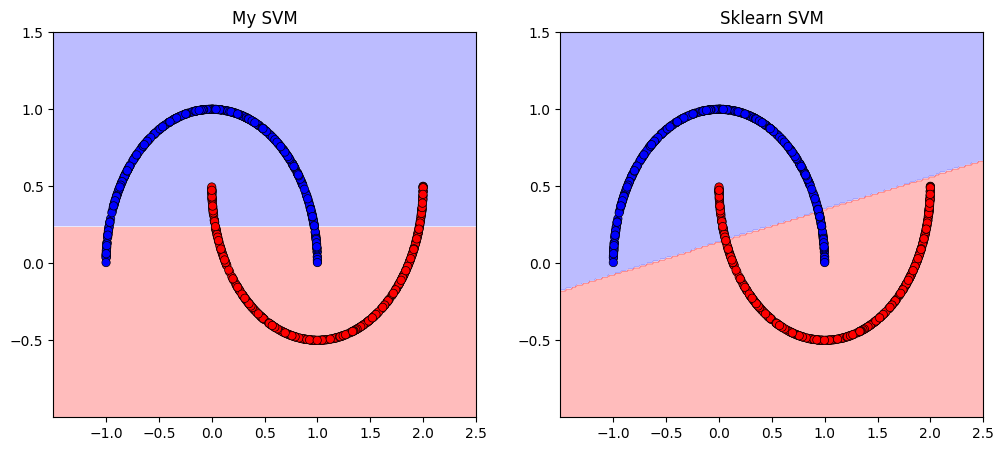

In [6]:
sk_svm = SVC(kernel='linear')
my_svm = LinearSVM()

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons)

sk_svm.fit(X_train_moons, y_train_moons)
my_svm.fit(X_train_moons, y_train_moons)

print_metrics(my_svm, X_test_moons, y_test_moons, "My SVM")
print_metrics(sk_svm, X_test_moons, y_test_moons, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_moons, y_test_moons, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_moons, y_test_moons, axes[1], "Sklearn SVM")
plt.show()

classification dataset


── My SVM ──
Confusion matrix:
[[359  37]
 [  9 386]]
Accuracy:       0.9418457648546145
Recall:         0.9772151898734177
Specificity:    0.9065656565656566

── Sklearn SVM ──
Confusion matrix:
[[366  30]
 [ 12 383]]
Accuracy:       0.9469026548672567
Recall:         0.9696202531645569
Specificity:    0.9242424242424242


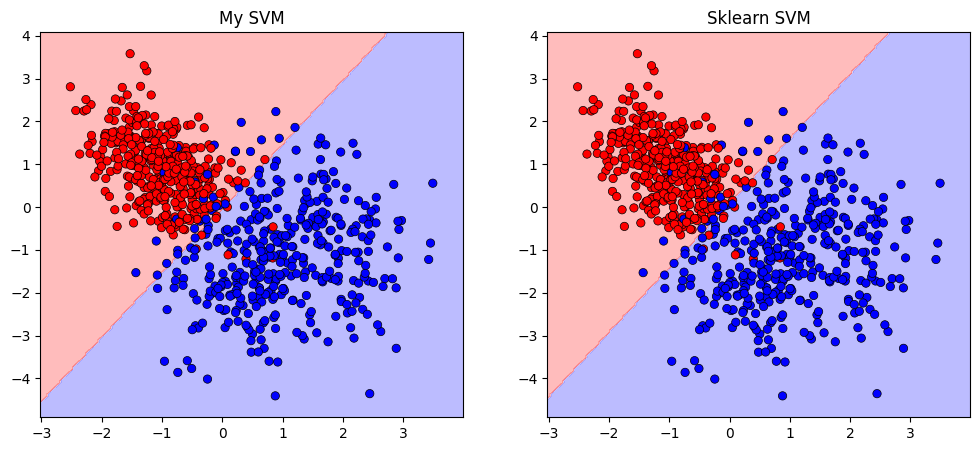

In [7]:
sk_svm = SVC(kernel='linear')
my_svm = LinearSVM()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE, stratify= y_classification)

my_svm.fit(X_train_clf, y_train_clf)
sk_svm.fit(X_train_clf, y_train_clf)

print_metrics(my_svm, X_test_clf, y_test_clf, "My SVM")
print_metrics(sk_svm, X_test_clf, y_test_clf, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_clf, y_test_clf, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_clf, y_test_clf, axes[1], "Sklearn SVM")
plt.show()

_________

# Non linear kernel implementation

In [8]:
from scipy.spatial.distance import cdist

class SVM(ClassifierAbstraction):
    def __init__(self, kernel : str = 'rbf', gamma = 'scale', degree = 3, r = 0.0, maxiter = MAXITER) -> None:
        self.bias = None
        self.lambdas = None
        self.kernel = kernel
        # training data
        self.X_train = None
        self.y_train = None
        self.maxiter = maxiter
        # params for kernels
        self.gamma = gamma
        self.degree = degree
        self.r = r

    def _rbf(self, X, Y):
        return np.exp(-self.gamma * cdist(X, Y, metric='sqeuclidean'))
        
    def _poly(self, X, Y):
        return (self.gamma * X @ Y.T + self.r) ** self.degree
    
    def _get_kernel(self, X, Y):
        if self.kernel == 'rbf':
            return self._rbf(X, Y)
        elif self.kernel == 'poly':
            return self._poly(X, Y)
        else:
            print(f"Unknown kernel: {self.kernel}")

    def _loss(self, lambdas, XX, yy):
            left_term = np.sum(lambdas)

            right_term = 0.5 * np.sum(np.outer(lambdas, lambdas) * yy * XX)

            return -(left_term - right_term)
    

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples, n_features = X.shape
        y = np.where(y == 0, -1, 1)

        if self.gamma == 'scale':
            self.gamma = 1 / (n_features * X.var())

        # XX = (X @ X.T) Linear case
        XX = self._get_kernel(X, X)
        yy = np.outer(y, y)

        self.X_train = X
        self.y_train = y

        lambdas_init = np.zeros(n_samples)

        bounds = [(0, None)] * n_samples

        result = minimize(
            fun=self._loss,
            x0=lambdas_init,
            args=(XX, yy),
            bounds=bounds,
            constraints={'type': 'eq', 'fun': lambda lambdas: np.dot(lambdas, y)},
            options={"maxiter": self.maxiter},
        )

        self.lambdas = result.x

        scores = (self.lambdas * y) @ XX

        sv_mask = self.lambdas > 1e-5
        self.bias = np.mean(y[sv_mask] - scores[sv_mask])
        # self.bias = np.mean(y - scores)
            
    def predict(self, X) -> np.ndarray:
        raw = np.sign(self.decision_function(X))
        return np.where(raw == -1, 0, 1)
    
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        K = self._get_kernel(X, self.X_train)             # (n_test, n_train)
        return K @ (self.lambdas * self.y_train) + self.bias

## Testing on synthetic data

### moons dataset

rbf kernel


── My SVM ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0

── Sklearn SVM ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0


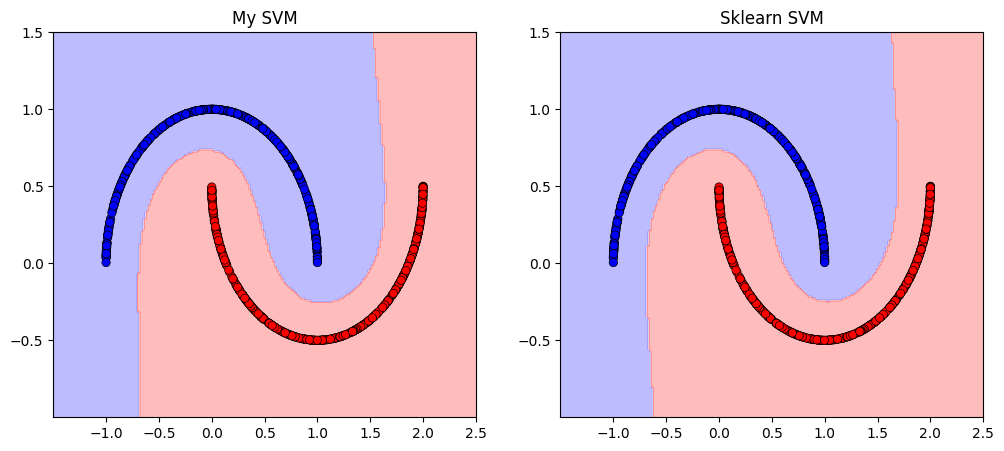

In [9]:
sk_svm = SVC(kernel='rbf')
my_svm = SVM(kernel='rbf')

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons)

sk_svm.fit(X_train_moons, y_train_moons)
my_svm.fit(X_train_moons, y_train_moons)

print_metrics(my_svm, X_test_moons, y_test_moons, "My SVM")
print_metrics(sk_svm, X_test_moons, y_test_moons, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_moons, y_test_moons, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_moons, y_test_moons, axes[1], "Sklearn SVM")
plt.show()

polynomial kernel


── My SVM ──
Confusion matrix:
[[396   0]
 [178 217]]
Accuracy:       0.7749683944374209
Recall:         0.549367088607595
Specificity:    1.0

── Sklearn SVM ──
Confusion matrix:
[[352  44]
 [  5 390]]
Accuracy:       0.9380530973451328
Recall:         0.9873417721518988
Specificity:    0.8888888888888888


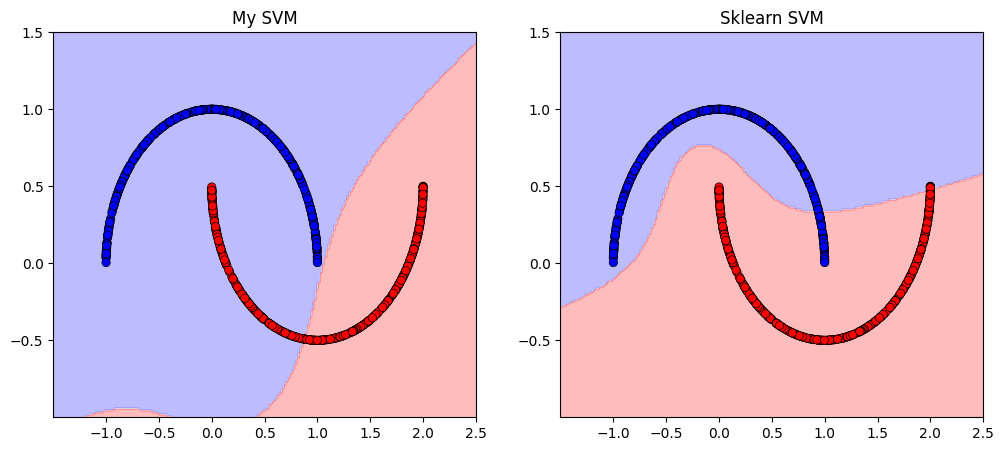

In [10]:
sk_svm = SVC(kernel='poly')
my_svm = SVM(kernel='poly')

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons)

sk_svm.fit(X_train_moons, y_train_moons)
my_svm.fit(X_train_moons, y_train_moons)

print_metrics(my_svm, X_test_moons, y_test_moons, "My SVM")
print_metrics(sk_svm, X_test_moons, y_test_moons, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_moons, y_test_moons, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_moons, y_test_moons, axes[1], "Sklearn SVM")
plt.show()

### classification dataset

rbf kernel


── My SVM ──
Confusion matrix:
[[306  90]
 [  5 390]]
Accuracy:       0.8798988621997471
Recall:         0.9873417721518988
Specificity:    0.7727272727272727

── Sklearn SVM ──
Confusion matrix:
[[367  29]
 [  7 388]]
Accuracy:       0.95448798988622
Recall:         0.9822784810126582
Specificity:    0.9267676767676768


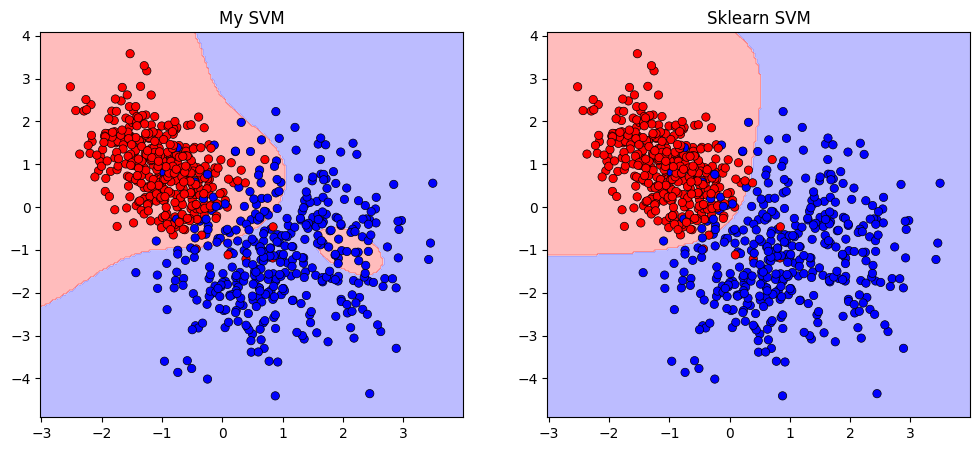

In [11]:
sk_svm = SVC(kernel='rbf')
my_svm = SVM(kernel='rbf')

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE, stratify=y_classification)

my_svm.fit(X_train_clf, y_train_clf)
sk_svm.fit(X_train_clf, y_train_clf)

print_metrics(my_svm, X_test_clf, y_test_clf, "My SVM")
print_metrics(sk_svm, X_test_clf, y_test_clf, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_clf, y_test_clf, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_clf, y_test_clf, axes[1], "Sklearn SVM")
plt.show()

polynomial kernel


── My SVM ──
Confusion matrix:
[[326  70]
 [  4 391]]
Accuracy:       0.9064475347661188
Recall:         0.9898734177215189
Specificity:    0.8232323232323232

── Sklearn SVM ──
Confusion matrix:
[[334  62]
 [  5 390]]
Accuracy:       0.9152970922882427
Recall:         0.9873417721518988
Specificity:    0.8434343434343434


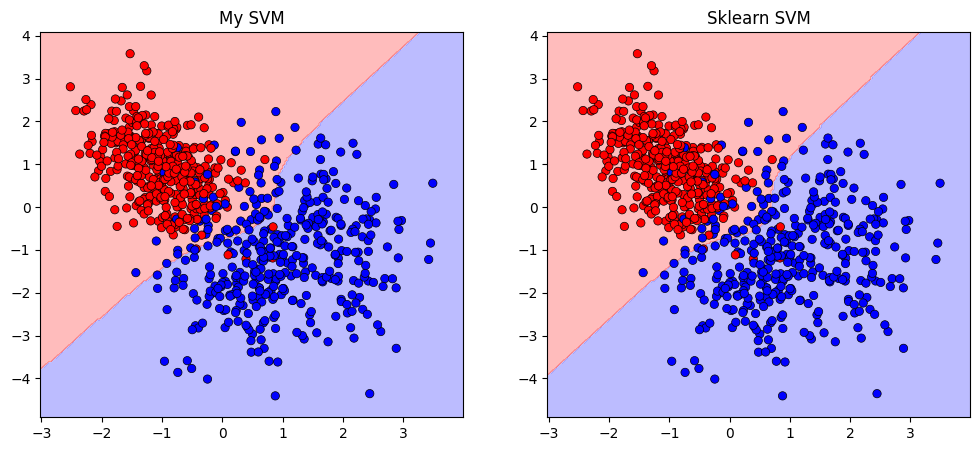

In [12]:
sk_svm = SVC(kernel='poly')
my_svm = SVM(kernel='poly')

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE, stratify=y_classification)

my_svm.fit(X_train_clf, y_train_clf)
sk_svm.fit(X_train_clf, y_train_clf)

print_metrics(my_svm, X_test_clf, y_test_clf, "My SVM")
print_metrics(sk_svm, X_test_clf, y_test_clf, "Sklearn SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_svm, X_test_clf, y_test_clf, axes[0], "My SVM")
plot_decision_boundary(sk_svm, X_test_clf, y_test_clf, axes[1], "Sklearn SVM")
plt.show()

___________

# Real data analysis with sklearn svm

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

### Loading

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/star_classification.csv")
df.head()

c:\Users\MatG\Desktop\UniStuff\MAGI\Podstawy uczenia maszynowego\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\MatG\.cache\kagglehub\datasets\fedesoriano\stellar-classification-dataset-sdss17\versions\1


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### Checking for empty data

In [15]:
df.isna().sum()
# df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

### Droping id columns

In [16]:
columns_to_drop = ['MJD', 'cam_col']

for col in df.columns:
    if col[-2:] == 'ID':
        columns_to_drop.append(col)

columns_to_drop

['MJD',
 'cam_col',
 'obj_ID',
 'run_ID',
 'rerun_ID',
 'field_ID',
 'spec_obj_ID',
 'fiber_ID']

In [17]:
df = df.drop(columns=columns_to_drop)
df.head(2)

,alpha,delta,u,g,r,i,z,class,redshift,plate
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,5812
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,10445


### Converting class to 1 or 0 and droping QSO

In [18]:
df['class'].unique()

<StringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str

In [19]:
df = df[df['class'].isin(['GALAXY', 'STAR'])] # removing qso
df['class'] = (df['class'] == 'GALAXY').astype(int)

In [20]:
df['class'].unique()

array([1, 0])

In [21]:
df.head(2)

,alpha,delta,u,g,r,i,z,class,redshift,plate
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,1,0.634794,5812
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,1,0.779136,10445


### Correlation matrix

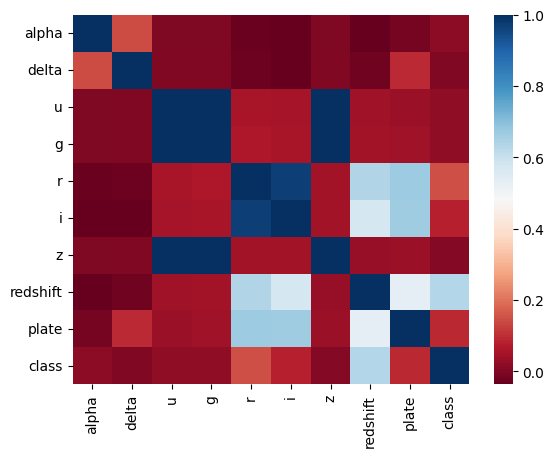

In [22]:
cols = [c for c in df.columns if c != 'class'] + ['class']
correlation = df[cols].corr()
plt.figure()
sns.heatmap(correlation, cmap='RdBu')
plt.show()

In [23]:
correlation

,alpha,delta,u,g,r,i,z,redshift,plate,class
alpha,1.000000,0.143788,-0.001512,-0.002692,-0.030298,-0.036391,-0.003711,-0.033389,-0.014703,0.017150
delta,0.143788,1.000000,0.003773,0.003870,-0.024545,-0.032801,0.002333,-0.021298,0.095854,0.000346
u,-0.001512,0.003773,1.000000,0.999455,0.055754,0.050049,0.998710,0.043348,0.035269,0.023778
g,-0.002692,0.003870,0.999455,1.000000,0.061225,0.056701,0.999384,0.046766,0.040913,0.021976
r,-0.030298,-0.024545,0.055754,0.061225,1.000000,0.969702,0.047265,0.638471,0.668888,0.147360
i,-0.036391,-0.032801,0.050049,0.056701,0.969702,1.000000,0.048603,0.572065,0.665249,0.078462
z,-0.003711,0.002333,0.998710,0.999384,0.047265,0.048603,1.000000,0.028678,0.032740,0.007263
redshift,-0.033389,-0.021298,0.043348,0.046766,0.638471,0.572065,0.028678,1.000000,0.532657,0.634963
plate,-0.014703,0.095854,0.035269,0.040913,0.668888,0.665249,0.032740,0.532657,1.000000,0.090946
class,0.017150,0.000346,0.023778,0.021976,0.147360,0.078462,0.007263,0.634963,0.090946,1.000000


### Splitting and normalizing data

In [24]:
X_real = df.drop(columns='class')
y_real = df['class']
X_real.head(2)

,alpha,delta,u,g,r,i,z,redshift,plate
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,5812
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,10445


In [25]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
                                                            X_real, y_real, test_size=0.3, random_state=RANDOM_STATE, stratify=y_real)

In [26]:
scaler = MinMaxScaler()

X_train_real = scaler.fit_transform(X_train_real)
X_test_real = scaler.transform(X_test_real)

In [27]:
X_train_real

array([[0.36639662, 0.58668494, 0.99971332, ..., 0.99904183, 0.27398017,
        0.35339142],
       [0.63535819, 0.61867469, 0.99943139, ..., 0.99902142, 0.1743069 ,
        0.06383845],
       [0.11023278, 0.45386414, 0.99913333, ..., 0.99885757, 0.00488753,
        0.23548571],
       ...,
       [0.49799374, 0.65753412, 0.99907967, ..., 0.99904551, 0.0048329 ,
        0.23670711],
       [0.44741974, 0.56976266, 0.99888622, ..., 0.9986367 , 0.03960573,
        0.09502484],
       [0.40062859, 0.63853099, 0.99929788, ..., 0.99897978, 0.20181119,
        0.58488722]], shape=(56727, 9))

### Using GridSearch for optimal parameters

Maxizing for recall because we dont want to miss any galaxies 

In [28]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    n_jobs = -1,
    scoring='recall',
)

grid_search.fit(X_train_real, y_train_real)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

evaluating the best one

Best params: {'C': 100, 'kernel': 'poly'}
Best recall: 0.9907

── Best SVM ──
Confusion matrix:
[[ 6478     0]
 [  162 17672]]
Accuracy:       0.9933366238894373
Recall:         0.9909162274307503
Specificity:    1.0


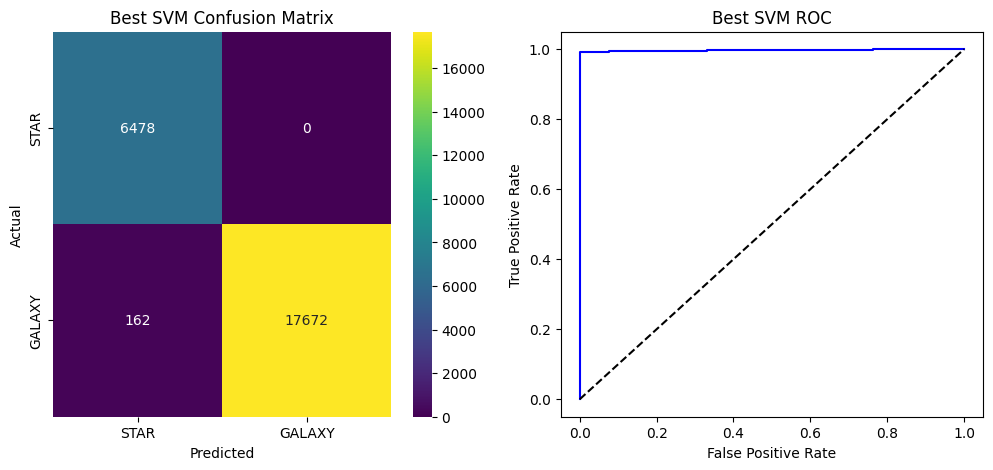

In [29]:
print(f"Best params: {grid_search.best_params_}")
print(f"Best recall: {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

print_metrics(best_svm, X_test_real, y_test_real, "Best SVM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(best_svm, X_test_real, y_test_real, axes[0], 
                      labels=['STAR', 'GALAXY'], title="Best SVM Confusion Matrix")
plot_roc(best_svm, X_test_real, y_test_real, axes[1], title="Best SVM ROC")
plt.show()